In [ ]:
import requests
from pprint import pprint
import json
from datetime import datetime
import time
import pandas as pd
import numpy as np

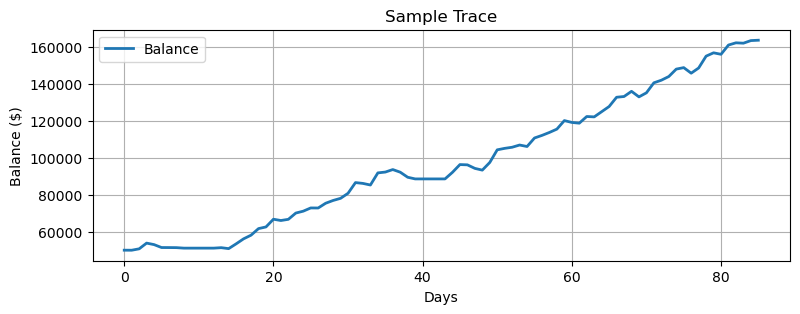

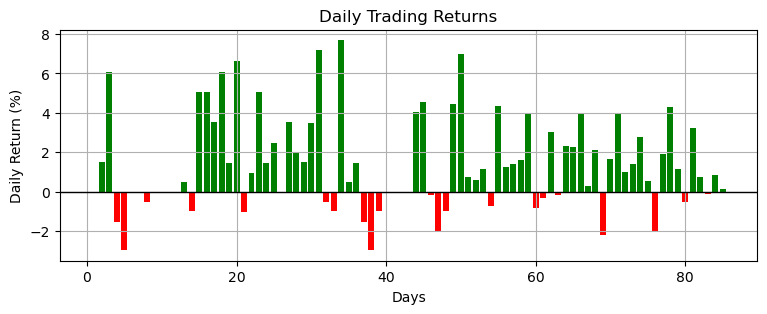

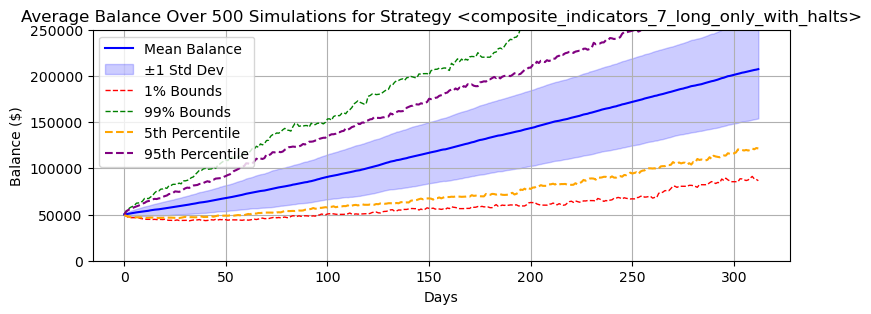

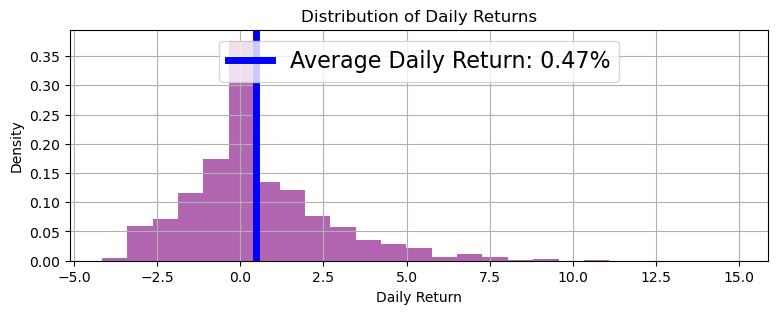

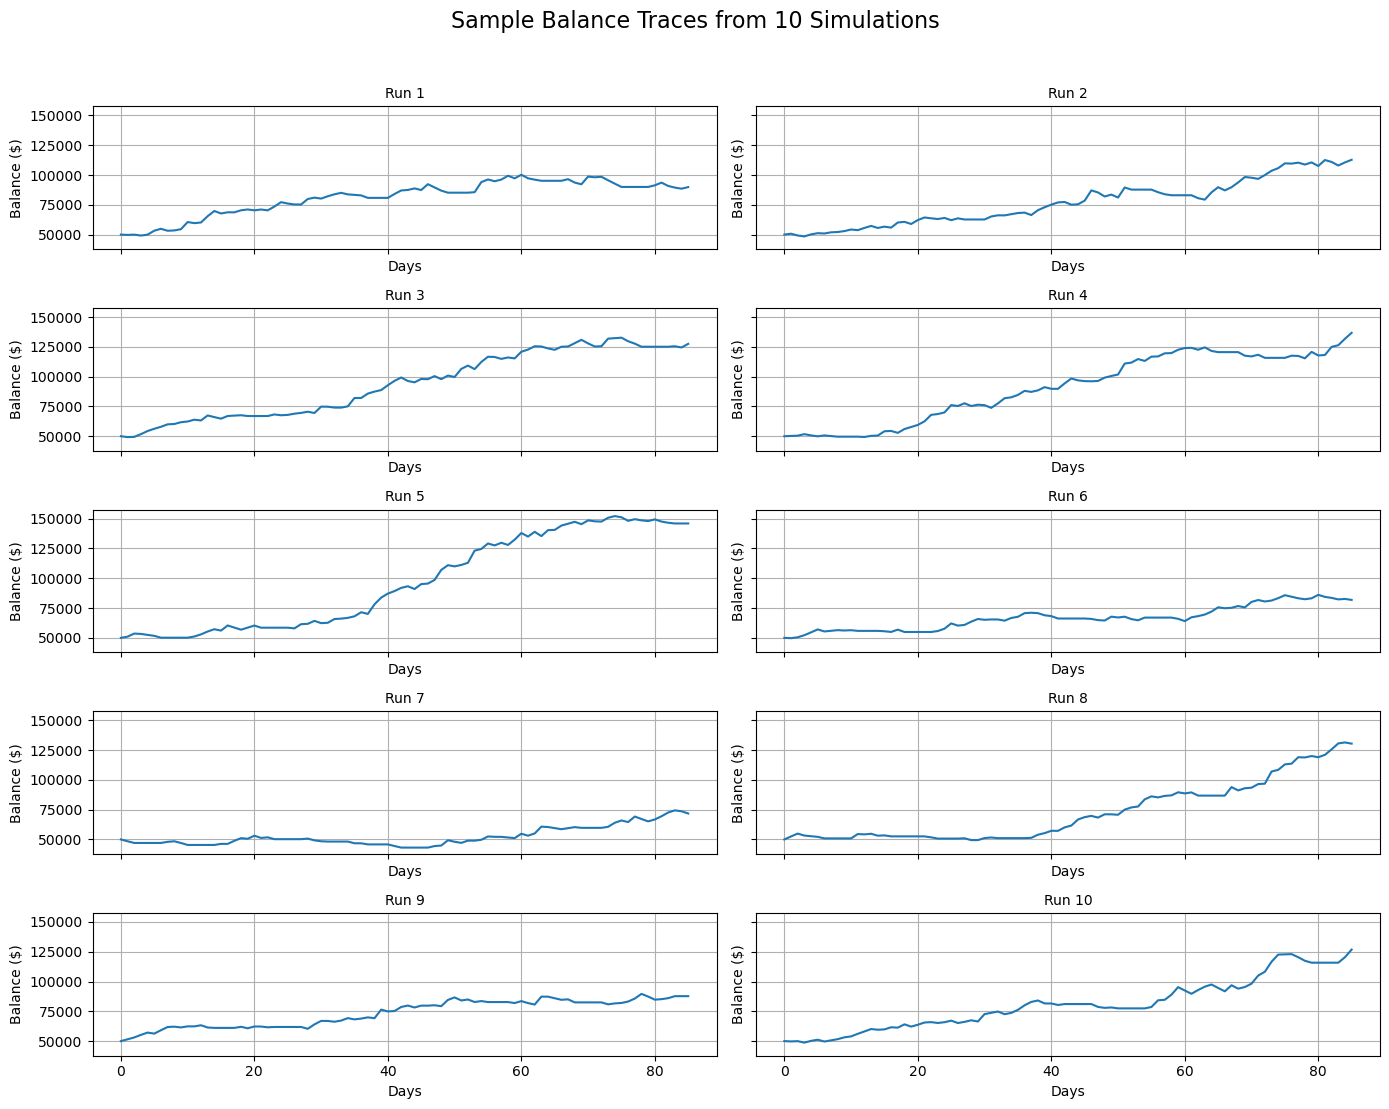

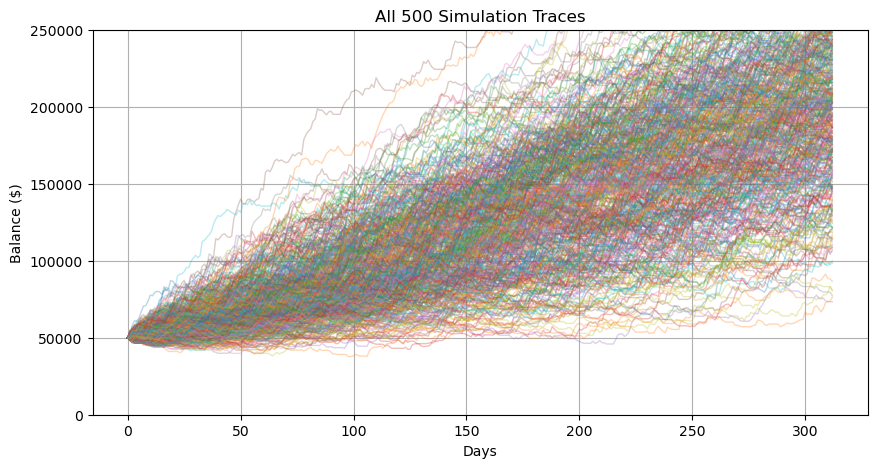

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

def simulate_trading(
    start_balance=50000,
    stop_loss=0.01,
    take_profit=0.015,
    win_rate=0.5,
    num_days=100,
    daily_loss_limit=3,
    weekly_loss_limit=6,
    show_plots=True,
    verbose=False
):
    balances = [start_balance]
    balance = start_balance
    daily_returns = []
    trade_results = []
    trade_days = []
    net_win_loss_log = []
    pause_days_remaining = 0

    for day in range(num_days):
        if day % 7 == 0:
            continue
        if pause_days_remaining > 0:
            if verbose:
                print('@', end='')
            net_win_loss_log.append(0)
            balances.append(balance)
            daily_returns.append(0)
            pause_days_remaining -= 1
            trade_results = []
            trade_days = []
            continue

        daily_start_balance = balance
        num_trades = random.randint(1, 10)
        consecutive_losses = 0

        for _ in range(num_trades):
            if consecutive_losses >= daily_loss_limit:
                if verbose:
                    print('!', end='')
                break

            recent_trades = [
                result for result, t_day in zip(trade_results, trade_days)
                if day - t_day < 7
            ]
            if sum(recent_trades) <= -weekly_loss_limit:
                pause_days_remaining = 3
                break

            trade_risk = balance * stop_loss
            trade_risk = min(trade_risk, 1000)
            trade_profit = balance * take_profit
            trade_profit = min(trade_profit, 1400)

            if random.random() < win_rate:
                balance += trade_profit
                trade_results.append(1)
                net_win_loss_log.append(1)
                consecutive_losses = 0
            else:
                balance -= trade_risk
                trade_results.append(-1)
                net_win_loss_log.append(-1)
                consecutive_losses += 1

            trade_days.append(day)

        daily_return = (balance - daily_start_balance) / daily_start_balance
        daily_returns.append(daily_return)
        balances.append(balance)
        
    return balances, daily_returns


def plot_multiple_traces(num_runs=10, rows=5, cols=2):
    fig, axes = plt.subplots(rows, cols, figsize=(14, 12), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten for easy indexing

    for i in range(num_runs):
        balances, daily_returns = simulate_trading(show_plots=False, verbose=False)
        axes[i].plot(balances, label="Balance", linewidth=1.5)
        axes[i].set_title(f"Run {i+1}", fontsize=10)
        axes[i].grid(True)

    for ax in axes:
        ax.set_xlabel("Days")
        ax.set_ylabel("Balance ($)")

    fig.suptitle("Sample Balance Traces from 10 Simulations", fontsize=16, y=0.92)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()



def plot_trading_results(balances, daily_returns):
    
        daily_returns_percent = np.array(daily_returns) * 100

        plt.figure(figsize=(9, 3))
        plt.plot(balances, label="Balance", linewidth=2)
        plt.xlabel("Days")
        plt.ylabel("Balance ($)")
        plt.title("Sample Trace")
        plt.legend()
        plt.grid()
        plt.show()

        plt.figure(figsize=(9,3))
        bar_colors = ['green' if ret > 0 else 'red' for ret in daily_returns_percent]
        plt.bar(range(1, len(daily_returns_percent) + 1), daily_returns_percent, color=bar_colors)
        plt.xlabel("Days")
        plt.ylabel("Daily Return (%)")
        plt.title("Daily Trading Returns")
        plt.axhline(0, color='black', linewidth=1)
        plt.grid()
        plt.show()
        
        
def run_multiple_simulations(
    num_simulations=100,
    **simulation_params
):
    all_balances = []
    all_returns = []

    for _ in range(num_simulations):
        balances, daily_returns = simulate_trading(show_plots=False, **simulation_params)
        all_balances.append(balances)
        all_returns.extend(daily_returns)

    all_balances = np.array(all_balances)
    mean_balance = np.mean(all_balances, axis=0)
    std_balance = np.std(all_balances, axis=0)

    days = np.arange(len(mean_balance))
    
    min_balance = np.percentile(all_balances, 1, axis=0)
    max_balance = np.percentile(all_balances, 99, axis=0)
    q_low = np.percentile(all_balances, 5, axis=0)
    q_high = np.percentile(all_balances, 95, axis=0)
    
    plt.figure(figsize=(9,3))
    plt.plot(days, mean_balance, label='Mean Balance', color='blue')
    plt.fill_between(
        days,
        mean_balance - std_balance,
        mean_balance + std_balance,
        color='blue',
        alpha=0.2,
        label='±1 Std Dev'
    )
    plt.plot(days, min_balance, color='red', linestyle='--', linewidth=1, label='1% Bounds')
    plt.plot(days, max_balance, color='green', linestyle='--', linewidth=1, label='99% Bounds')
    plt.plot(days, q_low, color='orange', linestyle='--', label='5th Percentile')
    plt.plot(days, q_high, color='purple', linestyle='--', label='95th Percentile')

    
    plt.xlabel("Days")
    plt.ylabel("Balance ($)")
    plt.title(f"Average Balance Over {num_simulations} Simulations for Strategy <composite_indicators_7_long_only_with_halts>")
    plt.ylim([0, 250000])
    plt.legend()
    plt.grid()
    plt.show()
    
    
    all_returns = np.array(all_returns) * 100
    return_mean = np.mean(all_returns)
    return_std = np.std(all_returns)
    return_min = np.min(all_returns)
    return_max = np.max(all_returns)

    # print(f"Daily Return Distribution:")
    # print(f"Mean: {return_mean:.4f}, Std: {return_std:.4f}, Min: {return_min:.4f}, Max: {return_max:.4f}")

    # Histogram with KDE-style smoothing
    plt.figure(figsize=(9,3))
    plt.hist(all_returns, bins=25, density=True, alpha=0.6, color='purple')
    plt.axvline(return_mean, 
                color='blue', 
                linestyle='-', 
                linewidth=5,
                label=f'Average Daily Return: {round(return_mean, 2)}%')
    plt.title("Distribution of Daily Returns")
    plt.xlabel("Daily Return")
    plt.ylabel("Density")
    plt.grid()
    plt.legend(fontsize=16, loc='upper center')
    plt.show()

    return mean_balance, std_balance, all_balances


def plot_all_traces(all_balances):
    num_runs = all_balances.shape[0]
    days = np.arange(all_balances.shape[1])
    
    plt.figure(figsize=(10, 5))
    for i in range(num_runs):
        plt.plot(days, all_balances[i], alpha=0.3, linewidth=1)

    plt.xlabel("Days")
    plt.ylabel("Balance ($)")
    plt.title(f"All {num_runs} Simulation Traces")
    plt.grid()
    plt.ylim([0, 250000])
    plt.show()


# Run a single simulation
b, dr = simulate_trading(verbose=False)
plot_trading_results(b, dr)

# Run 200 simulations and show confidence band
mean_balance, std_balance, all_balances = run_multiple_simulations(
                        num_simulations=500,
                        start_balance=50000,
                        stop_loss=0.01,
                        take_profit=0.014,
                        win_rate=0.48,
                        num_days=365,
                        daily_loss_limit=3,
                        weekly_loss_limit=7
                    )

plot_multiple_traces()
plot_all_traces(all_balances)

In [ ]:
API_KEY = 'b993b730-c03a-44b3-9438-37c44966209d'

exchanges = ['BITSTAMP', 'BINANCE', 'BINANCEUS', 'KRAKEN', 'COINBASE']
periods = ['5MIN', '15MIN', '1HRS', '4HRS', '1DAY', '7DAY', '1MTH']

symbols = {}
with open("coinapi_symbols_simple.json", "r") as json_file:
    symbols = json.load(json_file)

In [45]:
# function to get the symbol based on crypto and exchange
def get_symbol(crypto='BTC', exchange='KRAKEN', symbols_dict=symbols):
    if crypto in symbols_dict:
        if exchange in symbols_dict[crypto]['exchanges']:
            index = symbols_dict[crypto]['exchanges'].index(exchange)
            return symbols_dict[crypto]['symbols'][index]
    return None 


# function to get OHLCV using coinapi
# has default parameters for everything except api key
def _fetch_ohlcv(symbol='BITSTAMP_SPOT_BTC_USD', 
                period='1DAY', 
                time_start='2024-01-01T00:00:00', # T separates date from time, 24 hr format 
                time_end=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
                limit=1000,
                api_key=''):

    url = f"https://rest.coinapi.io/v1/ohlcv/{symbol}/history?period_id={period}&time_start={time_start}&time_end={time_end}&limit={limit}"
        
    headers = { "X-CoinAPI-Key": api_key } 
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        if response.content:
            return response.json()
        else:
            print("Response is empty.")
            return None
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}")
        return None
    

def fetch_ohlcv(symbol='BITSTAMP_SPOT_BTC_USD', 
                      period='1DAY', 
                      time_start='2024-01-01T00:00:00', 
                      time_end=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"), 
                      limit=1000, 
                      api_key=''):
    """
    Fetch full OHLCV data, bypassing API limits by making multiple requests.
    
    :param symbol: Trading pair symbol
    :param period: Timeframe (e.g., '1DAY', '1HRS')
    :param time_start: Start date in ISO format
    :param time_end: End date in ISO format
    :param limit: Max records per request (default: 1000)
    :param api_key: CoinAPI API key
    :return: List of OHLCV data points
    """
    all_data = []
    current_start = time_start
    
    while True:
        data = _fetch_ohlcv(symbol=symbol, period=period, time_start=current_start, time_end=time_end, limit=limit, api_key=api_key)
        
        if not data:
            print("No more data returned.")
            break
        
        all_data.extend(data)
        
        # Stop if we received fewer than the max `limit` (no more data to fetch)
        if len(data) < limit:
            break
        
        # Get last timestamp and use it as new start time for the next request
        last_timestamp = data[-1]['time_period_end']
        current_start = last_timestamp  # Continue fetching from last returned time
        print(last_timestamp)
        
        # Respect API rate limits
        time.sleep(7)  # Adjust delay as needed based on CoinAPI rate limits
    
    return all_data


In [86]:
# get the proper symbol, defaults to kraken exchange if no exchange is provided
symbol = get_symbol('BTC', symbols_dict=symbols)

d = fetch_ohlcv(symbol=symbol, period='1HRS', time_start='2021-08-16T17:00:00', time_end='2022-01-01T00:00:00', api_key=API_KEY)
df2 = pd.DataFrame(d)
del d
df = pd.concat([df, df2])
df.reset_index(inplace=True, drop=True)
df

2021-09-27T09:00:00.0000000Z
2021-11-08T01:00:00.0000000Z
2021-12-19T17:00:00.0000000Z


,time_period_start,time_period_end,time_open,time_close,price_open,price_high,price_low,price_close,volume_traded,trades_count
0,2019-01-01T00:00:00.0000000Z,2019-01-01T01:00:00.0000000Z,2019-01-01T00:00:00.4730000Z,2019-01-01T00:59:44.5680000Z,3690.9,3704.9,3683.2,3694.5,248.481814,627
1,2019-01-01T01:00:00.0000000Z,2019-01-01T02:00:00.0000000Z,2019-01-01T01:00:02.5780000Z,2019-01-01T01:59:52.0650000Z,3690.6,3694.4,3677.1,3682.8,125.360963,331
2,2019-01-01T02:00:00.0000000Z,2019-01-01T03:00:00.0000000Z,2019-01-01T02:00:17.9330000Z,2019-01-01T02:58:27.0540000Z,3682.8,3687.8,3668.8,3676.9,123.738825,350
3,2019-01-01T03:00:00.0000000Z,2019-01-01T04:00:00.0000000Z,2019-01-01T03:00:35.6440000Z,2019-01-01T03:59:13.2780000Z,3679.2,3687.8,3677.4,3685.3,41.372428,180
4,2019-01-01T04:00:00.0000000Z,2019-01-01T05:00:00.0000000Z,2019-01-01T04:00:02.3630000Z,2019-01-01T04:59:45.8310000Z,3685.4,3699.5,3674.5,3683.6,123.947133,435
...,...,...,...,...,...,...,...,...,...,...
26032,2021-12-31T19:00:00.0000000Z,2021-12-31T20:00:00.0000000Z,2021-12-31T19:00:03.3620000Z,2021-12-31T19:59:56.5040000Z,46671.8,46671.8,45530.3,45705.3,469.598338,3307
26033,2021-12-31T20:00:00.0000000Z,2021-12-31T21:00:00.0000000Z,2021-12-31T20:00:00.2100000Z,2021-12-31T20:59:56.1840000Z,45705.3,46206.0,45651.5,45867.0,196.945965,1545
26034,2021-12-31T21:00:00.0000000Z,2021-12-31T22:00:00.0000000Z,2021-12-31T21:00:01.6830000Z,2021-12-31T21:59:48.7710000Z,45867.0,46480.0,45801.3,46340.8,208.385288,1536
26035,2021-12-31T22:00:00.0000000Z,2021-12-31T23:00:00.0000000Z,2021-12-31T22:00:02.3070000Z,2021-12-31T22:59:56.3920000Z,46340.8,46543.0,46263.0,46326.4,67.047519,848


In [88]:
def get_halving_position(date):
    # Bitcoin Halving Dates
    halving_dates = [
        datetime(2012, 11, 28),
        datetime(2016, 7, 9),
        datetime(2020, 5, 11),
        datetime(2024, 4, 19),
        datetime(2028, 4, 20)  # Estimated next halving
    ]

    if date.tzinfo is not None:
        date = date.tz_localize(None)
        
    for i in range(len(halving_dates) - 1):
        if halving_dates[i] <= date < halving_dates[i + 1]:
            cycle_length = (halving_dates[i + 1] - halving_dates[i]).total_seconds()
            position = (date - halving_dates[i]).total_seconds() / cycle_length
            return position
    return 1.0  # Beyond last known halving



def add_features(df):
    # Load DataFrame (Assuming it has 'time_period_start' column)
    df["time_period_start"] = pd.to_datetime(df["time_period_start"])

    # Create sinusoidal features
    df["sin_hour"] = np.sin(2 * np.pi * df["time_period_start"].dt.hour  / 24)

    df["sin_day_of_week"] = np.sin(2 * np.pi * df["time_period_start"].dt.dayofweek / 7)

    df["sin_day_of_year"] = np.sin(2 * np.pi * df["time_period_start"].dt.dayofyear / 365)

    # Compute Bitcoin Halving Cycle Position
    df["halving_position"] = df["time_period_start"].apply(get_halving_position)

    df["avg_price"] = (df["price_open"] + df["price_low"] + df["price_high"] + df["price_close"]) / 4

    # Convert BTC volume to USD
    df["volume_traded_usd"] = df["volume_traded"] * df["avg_price"]
    
    


In [89]:
df.drop(columns=['time_open', 'time_close'], inplace=True)
add_features(df)
df.to_csv('btc_2019-01-01_2021-12-31_hourly.csv')
df

,time_period_start,time_period_end,price_open,price_high,price_low,price_close,volume_traded,trades_count,sin_hour,sin_day_of_week,sin_day_of_year,halving_position,avg_price,volume_traded_usd
0,2019-01-01 00:00:00+00:00,2019-01-01T01:00:00.0000000Z,3690.9,3704.9,3683.2,3694.5,248.481814,627,0.000000,0.781831,1.721336e-02,0.646220,3693.375,9.177365e+05
1,2019-01-01 01:00:00+00:00,2019-01-01T02:00:00.0000000Z,3690.6,3694.4,3677.1,3682.8,125.360963,331,0.258819,0.781831,1.721336e-02,0.646249,3686.225,4.621087e+05
2,2019-01-01 02:00:00+00:00,2019-01-01T03:00:00.0000000Z,3682.8,3687.8,3668.8,3676.9,123.738825,350,0.500000,0.781831,1.721336e-02,0.646279,3679.075,4.552444e+05
3,2019-01-01 03:00:00+00:00,2019-01-01T04:00:00.0000000Z,3679.2,3687.8,3677.4,3685.3,41.372428,180,0.707107,0.781831,1.721336e-02,0.646309,3682.425,1.523509e+05
4,2019-01-01 04:00:00+00:00,2019-01-01T05:00:00.0000000Z,3685.4,3699.5,3674.5,3683.6,123.947133,435,0.866025,0.781831,1.721336e-02,0.646339,3685.750,4.568381e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26032,2021-12-31 19:00:00+00:00,2021-12-31T20:00:00.0000000Z,46671.8,46671.8,45530.3,45705.3,469.598338,3307,-0.965926,-0.433884,6.432491e-16,0.416811,46144.800,2.166952e+07
26033,2021-12-31 20:00:00+00:00,2021-12-31T21:00:00.0000000Z,45705.3,46206.0,45651.5,45867.0,196.945965,1545,-0.866025,-0.433884,6.432491e-16,0.416840,45857.450,9.031440e+06
26034,2021-12-31 21:00:00+00:00,2021-12-31T22:00:00.0000000Z,45867.0,46480.0,45801.3,46340.8,208.385288,1536,-0.707107,-0.433884,6.432491e-16,0.416869,46122.275,9.611204e+06
26035,2021-12-31 22:00:00+00:00,2021-12-31T23:00:00.0000000Z,46340.8,46543.0,46263.0,46326.4,67.047519,848,-0.500000,-0.433884,6.432491e-16,0.416898,46368.300,3.108879e+06
